In [1]:
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib
import corner
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
from matplotlib.colors import LogNorm

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
sns.set(font_scale=1.8)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Times New Roman'

cmap = plt.get_cmap("rainbow")
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

import BaryonForge as bfg
import pyccl as ccl
from scipy.integrate import cumulative_trapezoid, simpson
from astropy import constants as con
import os

os.environ["PK_MODEL"] = "BCEmu7"
os.environ["METHOD"] = "exact"
os.environ["N_FRB"]    = "100"
os.environ["N_PARAMS"] = "1"
from mcmc_funcs import *
from sensitivity_funcs import *
from astropy.cosmology import Planck18 as cosmo

G = con.G.cgs.value
m_p = con.m_p.cgs.value
c = con.c.cgs.value
pc = con.pc.cgs.value; Mpc = 1e6*pc
chi_e = 1 - (0.2453 / 2)


Not using emulators.
Unknown Pk_model!


In [2]:
class DMvarianceSensitivityCalculator:
    def __init__(self, cosmo_calc, logMmax, compute_dDM_dk=False):
        self.cosmo = cosmo_calc
        self.logMmax = logMmax
        k_fields = np.geomspace(1e-4, 100, 1000); self.k_fields = k_fields
        self.z_grid = np.linspace(0.0001, 3, 200)
        self.compute_dDM_dk = compute_dDM_dk
    
    def get_Pgas_BCEmu1(self, log_Mc, z_arr, log10M_max=16, log10M_min=6):
        Ob0 = self.cosmo.Ob0
        Om0 = self.cosmo.Om0

        fft_precision = dict(padding_lo_fftlog = 1e-8, padding_hi_fftlog = 1e8, n_per_decade = 500)
        h = self.cosmo.H0/(1e5/Mpc)/100
        
        ccl_cosmo = ccl.Cosmology(Omega_c = Om0-Ob0, 
                                  Omega_b = Ob0, 
                                  h = h,
                                  sigma8 = 0.8111, 
                                  n_s = 0.9665, 
                                  matter_power_spectrum='linear'
                                 )

        P_GAS = []
        for z in z_arr:
            rho  = ccl.rho_x(ccl_cosmo, 1/(1+z), 'matter', is_comoving = True)
            par = dict(theta_ej=4.93, theta_co=0.1, M_c=(10**log_Mc)/h, mu_beta=0.94, 
                       eta=0.22, eta_delta=0.21, tau=-1.5, tau_delta=0, A=0.055/2, 
                       M1=2.5e11/h, epsilon_h=0.015, a=0.3, n=2, epsilon=4, p=0.3, 
                       q=0.707, gamma=2.79, delta=7.33)
            DMO = bfg.Profiles.Schneider19.DarkMatter(**par, r_min_int = 1e-3, r_max_int = 1e2, r_steps = 500)
            GAS = bfg.Profiles.Schneider19.Gas(**par, r_min_int = 1e-3, r_max_int = 1e2, r_steps = 500)
            M_2_Mtot = bfg.Profiles.misc.Mdelta_to_Mtot(DMO, r_min = 1e-6, r_max = 1e2, N_int = 100)
            GAS = GAS / (rho*Ob0/Om0)
            T   = bfg.Profiles.misc.Truncation(epsilon_trunc = 100)
            GAS = GAS * T
            for p in [GAS]: p.update_precision_fftlog(**fft_precision)
            HMC_flex = HMCalculator_NoCorrection(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
                                                 mass_def = ccl.halos.massdef.MassDef200c, 
                                                 log10M_min = log10M_min, log10M_max = log10M_max, nM = 100)

            P_GAS.append(ccl.halos.pk_2pt.halomod_power_spectrum(ccl_cosmo, HMC_flex, self.k_fields, 1/(1+z), GAS, suppress_1h = lambda k : 1e-2, get_2h=True))
        return np.array(P_GAS)
    
    
    def get_power_spectra(self, fp, Pk_model, log10M_max=16, log10M_min=6):
        if Pk_model == "BCEmu1":
            Pk_fields = self.get_Pgas_BCEmu1(fp["log_Mc"], self.z_grid, log10M_max, log10M_min)
        else:
            raise ValueError("Unknown Pk_model!")
        self.P_gas = Pk_fields
    
    
    def get_DM_variance(self, fp, Pk_model, log10M_max=16, log10M_min=6, compute_dDM_dk=False):
        Ob0 = self.cosmo.Ob0
        Om0 = self.cosmo.Om0
        H0 = self.cosmo.H0
        
        integrand_zk = self.P_gas
        integrand_z = (simpson(y=(self.k_fields * integrand_zk / (2 * np.pi)), x=self.k_fields, axis=1)) * Mpc

        Hz = H0 * np.sqrt(Om0*(1 + self.z_grid)**3 + (1 - Om0))
        integrand_z = ((1 + self.z_grid)**2 / Hz) * integrand_z
        rho_c0 = 3 * (H0**2) / (8 * np.pi * G)
        ne0_bar = Ob0 * rho_c0 * chi_e / m_p
        
        f_d = f_diffuse(np.array([H0]), np.array([Ob0]), np.array([Om0]), np.array([0.8111]), 
                        np.array([
                          {"log_Mc": fp["log_Mc"], "theta_ej": 4.93, 
                           "eta_delta": 0.21, "delta": 7.33, 
                           "mu_beta": 0.94, "gamma": 2.79, 
                           "eta": 0.22, "A": 0.055/2, "tau": -1.5
                          } for i in (range(1))]), 
                        "BCEmu7", self.z_grid)   
        
        self.dDMmean_dz = ((3 * c * chi_e * Ob0*H0) / (8 * np.pi * G * m_p)) * f_d * (1+self.z_grid)/np.sqrt(Om0*(1 + self.z_grid)**3 + (1 - Om0))
        self.DMmean = cumulative_trapezoid(y=self.dDMmean_dz, x=self.z_grid, initial=0)
        
        integrand_z *= c * (ne0_bar**2); self.dDMvar_dz = (integrand_z/(pc**2))
        integral = cumulative_trapezoid(y=integrand_z, x=self.z_grid, initial=0)
        DMvar = (integral / (pc**2))**0.5; self.DMvar = DMvar
        
        DMvar_k = []
        for i in range(len(self.k_fields)-1):
            i+=1
            integrand_zk = self.P_gas
            integrand_z = (simpson(y=(self.k_fields[:i] * integrand_zk[:, :i] / (2 * np.pi)), x=self.k_fields[:i], axis=1)) * Mpc
            
            Hz = H0 * np.sqrt(Om0*(1 + self.z_grid)**3 + (1 - Om0))
            integrand_z = ((1 + self.z_grid)**2 / Hz) * integrand_z
            rho_c0 = 3 * (H0**2) / (8 * np.pi * G)
            ne0_bar = Ob0 * rho_c0 * chi_e / m_p
            integrand_z *= c * (ne0_bar**2); self.dDMvar_dz = (integrand_z/(pc**2))
            integral = cumulative_trapezoid(y=integrand_z, x=self.z_grid, initial=0)
            DMvar = (integral / (pc**2))**0.5; DMvar_k.append(DMvar)
        self.DMvar_k = np.array(DMvar_k)



In [3]:
H0 = cosmo.H0.cgs.value; Ob0 = cosmo.Ob0; Om0 = cosmo.Om0; sigma8 = 0.8111

mu_host=5; sigma_host=0.5
DMhost_mean = pc*np.exp(mu_host); DMhost_var = (pc**2)*(np.exp((2*mu_host)+(sigma_host**2)))*((np.exp(sigma_host**2))-1)

cosmo_calc = CosmologyCalculator(H0, Ob0, Om0, sigma8)



In [4]:
from joblib import Parallel, delayed

logMmaxs = np.linspace(10, 16, 100)

# def run_one(logMmax):
#     power_spectra_object = DMvarianceSensitivityCalculator(
#         cosmo_calc, frb_dist, lmin=lmin, lmax=lmax, logMmax=logMmax
#     )
#     power_spectra_object.get_power_spectra({"log_Mc": 12.84}, Pk_model="BCEmu1", log10M_max=power_spectra_object.logMmax)
#     power_spectra_object.get_DM_variance({"log_Mc": 12.84}, Pk_model="BCEmu1", log10M_max=power_spectra_object.logMmax, compute_dDM_dk=power_spectra_object.compute_dDM_dk)
      
#     return {
#         "DMvars": power_spectra_object.DMvar,
#         "dDMvar_dz": power_spectra_object.dDMvar_dz,
#         "dDMvar_k": power_spectra_object.DMvar_k
#     }

# power_spectra_object = Parallel(n_jobs=4)(
#     delayed(run_one)(logMmaxs[i]) for i in tqdm(range(len(logMmaxs)))
# )

# np.save("data/sensitivity/power_spectra_object_currentFRBs_1h.npy", power_spectra_object, allow_pickle=True)



# def run_one(logMmax):
#     power_spectra_object = DMvarianceSensitivityCalculator(
#         cosmo_calc, lmin=lmin, lmax=lmax, logMmax=logMmax
#     )
#     power_spectra_object.get_power_spectra({"log_Mc": 12.84}, Pk_model="BCEmu1", log10M_max=power_spectra_object.logMmax)
#     power_spectra_object.get_DM_variance({"log_Mc": 12.84}, Pk_model="BCEmu1", log10M_max=power_spectra_object.logMmax, compute_dDM_dk=power_spectra_object.compute_dDM_dk)
      
#     return {
#         "DMvars": power_spectra_object.DMvar,
#         "dDMvar_dz": power_spectra_object.dDMvar_dz,
#         "dDMvar_k": power_spectra_object.DMvar_k
#     }

# power_spectra_object = Parallel(n_jobs=4)(
#     delayed(run_one)(logMmaxs[i]) for i in tqdm(range(len(logMmaxs)))
# )

# np.save("data/sensitivity/power_spectra_object_DSA2000FRBs_1h.npy", power_spectra_object, allow_pickle=True)


power_spectra_object = DMvarianceSensitivityCalculator(
        cosmo_calc, logMmax=16
    )
power_spectra_object.get_power_spectra({"log_Mc": 12.84}, Pk_model="BCEmu1", log10M_max=power_spectra_object.logMmax)
power_spectra_object.get_DM_variance({"log_Mc": 12.84}, Pk_model="BCEmu1", log10M_max=power_spectra_object.logMmax, compute_dDM_dk=power_spectra_object.compute_dDM_dk)
      
dDMmean_dz = power_spectra_object.dDMmean_dz[0]/pc
DMmean = power_spectra_object.DMmean[0]/pc
DMvar = power_spectra_object.DMvar



In [5]:
levels = np.array([0.33, 0.66])

z_grid = power_spectra_object.z_grid
power_spectra_object = np.load("data/sensitivity/power_spectra_object_currentFRBs_1h.npy", allow_pickle=True)
k_fields = np.geomspace(1e-4, 100, 1000)

DMvars = np.array([power_spectra_object[i]["DMvars"] for i in range(100)])
dDMvar_dz = np.array([power_spectra_object[i]["dDMvar_dz"] for i in range(100)])
dDMvar_k = np.array([power_spectra_object[i]["dDMvar_k"] for i in range(100)])


dDMvar_z_dlogM = np.gradient(DMvars, logMmaxs, axis=0)
dDMvarsq_z_dlogM = np.gradient(DMvars**2, logMmaxs, axis=0)

dDMvar_z_dk = np.gradient(dDMvar_k[-1], k_fields[1:], axis=0)
dDMvarsq_z_dk = np.gradient(dDMvar_k[-1]**2, k_fields[1:], axis=0)

from scipy.interpolate import interp1d

dDMvarsq_z_dlogM_interp_z = interp1d(
    z_grid,
    dDMvarsq_z_dlogM,
    axis=1,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)
dDMvar_z_dlogM_interp_z = interp1d(
    z_grid,
    dDMvar_z_dlogM,
    axis=1,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

dDMvarsq_z_dk_interp_z = interp1d(
    z_grid,
    dDMvarsq_z_dk,
    axis=1,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)
dDMvar_z_dk_interp_z = interp1d(
    z_grid,
    dDMvar_z_dk,
    axis=1,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

dDMvar_z_dz_interp_z = interp1d(
    z_grid,
    dDMvar_dz[-1],
    axis=0,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

sigma_l = np.sqrt(np.log10(1+((DMvar**2+(100/(1+z_grid))**2)/DMmean**2)))


In [6]:
df = pd.read_csv("data/frb_results/frb_sample.csv")
df = df[np.logical_or(df["sharma_sample"]=="yes", df["sharma_sample"]=="unclear")].reset_index()
df.head()

,index,FRB,ra[deg],dec[deg],p_host,DMobs,DM_MW,z_sample,DMexgal,survey,Reference,reischke_sample,connor_sample,sharma_sample,sharma_reason_for_excluding/notes,redshift_type,l[deg],b[deg]
0,0,FRB 20240304B,182.997,11.813,0.975,2458.20,28.11,2.148,2430.09,MeerKAT,Caleb+2025,no,no,yes,Beyond HMcode range; careful!,spec,269.868,72.104
1,1,FRB 20230521B,351.036,71.138,0.968,1342.90,138.75,1.354,1204.15,DSA-110,Connor+2025,yes,yes,yes,NaN,spec,115.934,9.462
2,2,FRB 20240104A,348.874,72.821,0.990,1348.90,120.67,1.330,1228.23,DSA-110,Verdi+2025,no,no,yes,NaN,spec,115.900,11.272
3,3,FRB 20220610A,351.073,-33.514,1.000,1457.62,30.94,1.016,1426.68,ASKAP,"Ryder+2023, Gordon+2024, Shannon+2024",yes,yes,yes,NaN,spec,8.839,-70.186
4,4,FRB 20221029A,141.966,72.452,0.920,1391.05,43.91,0.975,1347.14,DSA-110,"Sherman+2024, Connor+2025, Sharma+2024",yes,yes,yes,NaN,spec,140.003,37.158


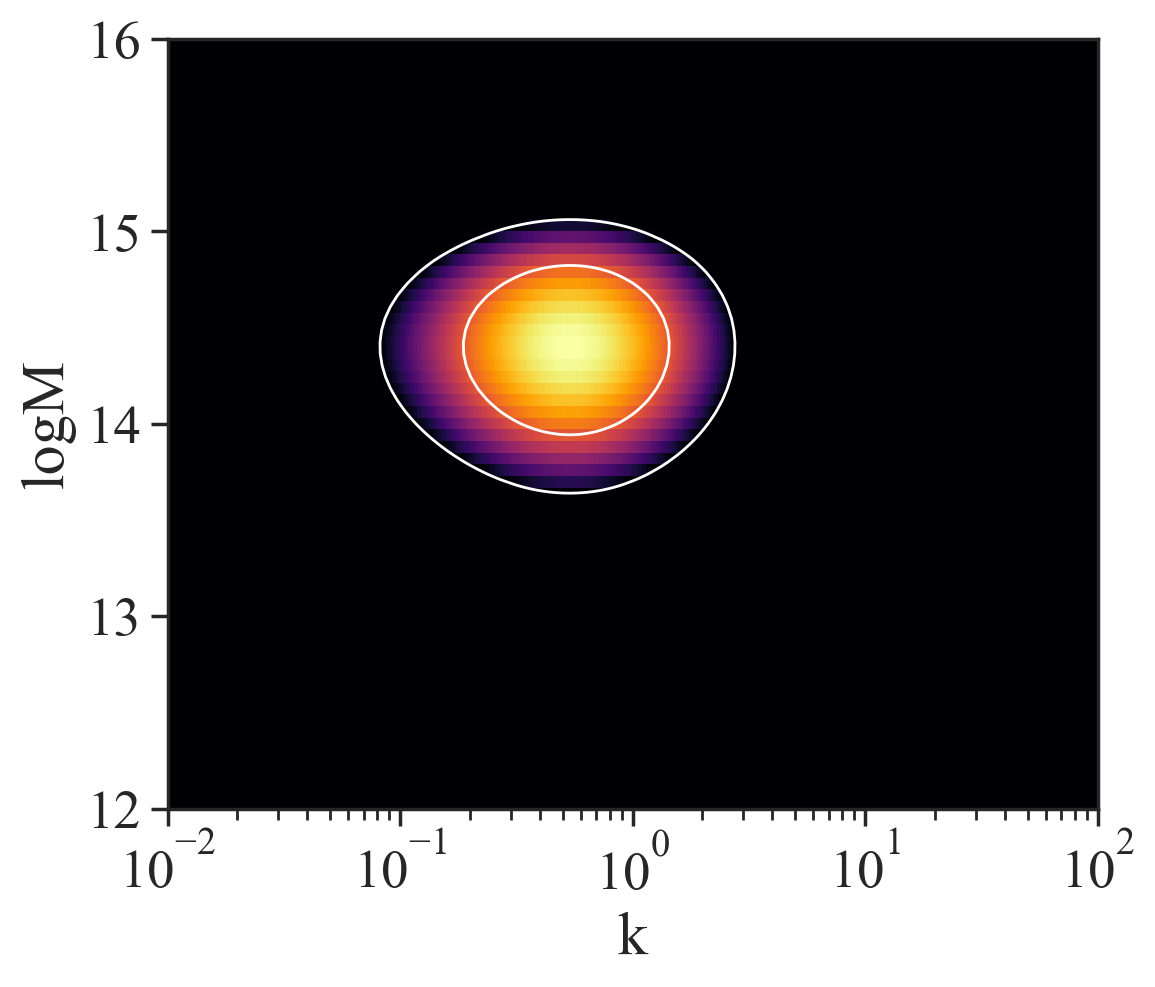

In [7]:
sensitivity_total = np.zeros((len(logMmaxs), len(k_fields[1:])))
for frb_z in df.z_sample:
    DMmean_FRB = np.interp(frb_z, z_grid, DMmean)
    DMstd_FRB = np.interp(frb_z, z_grid, DMvar)
    
    dDMmean_dz_FRB = np.where(z_grid<frb_z, dDMmean_dz, 0)
    dDMvar_dz_FRB = np.where(z_grid<frb_z, dDMvar_dz[-1], 0)
    
    d_mu_l_dlogM = -(1/(DMmean_FRB**2 + DMstd_FRB**2 + (100/(1+frb_z))**2)) * 0.5*dDMvarsq_z_dlogM_interp_z(frb_z)
    d_mu_l_dk = -(1/(DMmean_FRB**2 + DMstd_FRB**2 + (100/(1+frb_z))**2)) * 0.5*dDMvarsq_z_dk_interp_z(frb_z)
    
    sensitivity = d_mu_l_dlogM[:, None]*d_mu_l_dk[None, :]/(np.interp(frb_z, z_grid, sigma_l)**2)

    sensitivity[sensitivity<1e-100] = 1e-100
    sensitivity[np.isnan(sensitivity)] = 1e-100
    sensitivity_total += sensitivity
sensitivity_total /= np.max(sensitivity_total)
sensitivity_MK_CURRENT = sensitivity_total

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.pcolormesh(k_fields[1:], logMmaxs, sensitivity_total, cmap="inferno", norm=LogNorm(0.33, 1))

Z, M = np.meshgrid(k_fields[1:], logMmaxs)
contours = ax.contour(Z, M, sensitivity_total, levels=levels, colors='white', linewidths=1.0)

ax.set_ylabel("logM")
ax.set_xlabel("k")

ax.set_xlim(1e-2, 1e2)
ax.set_ylim(12, 16)
ax.set_xscale('log')

# np.save("data/sensitivity/sensitivity_currentFRBs_DMvar_MK.npy", np.array([Z, M, sensitivity_MK_CURRENT]))


(12.0, 16.0)

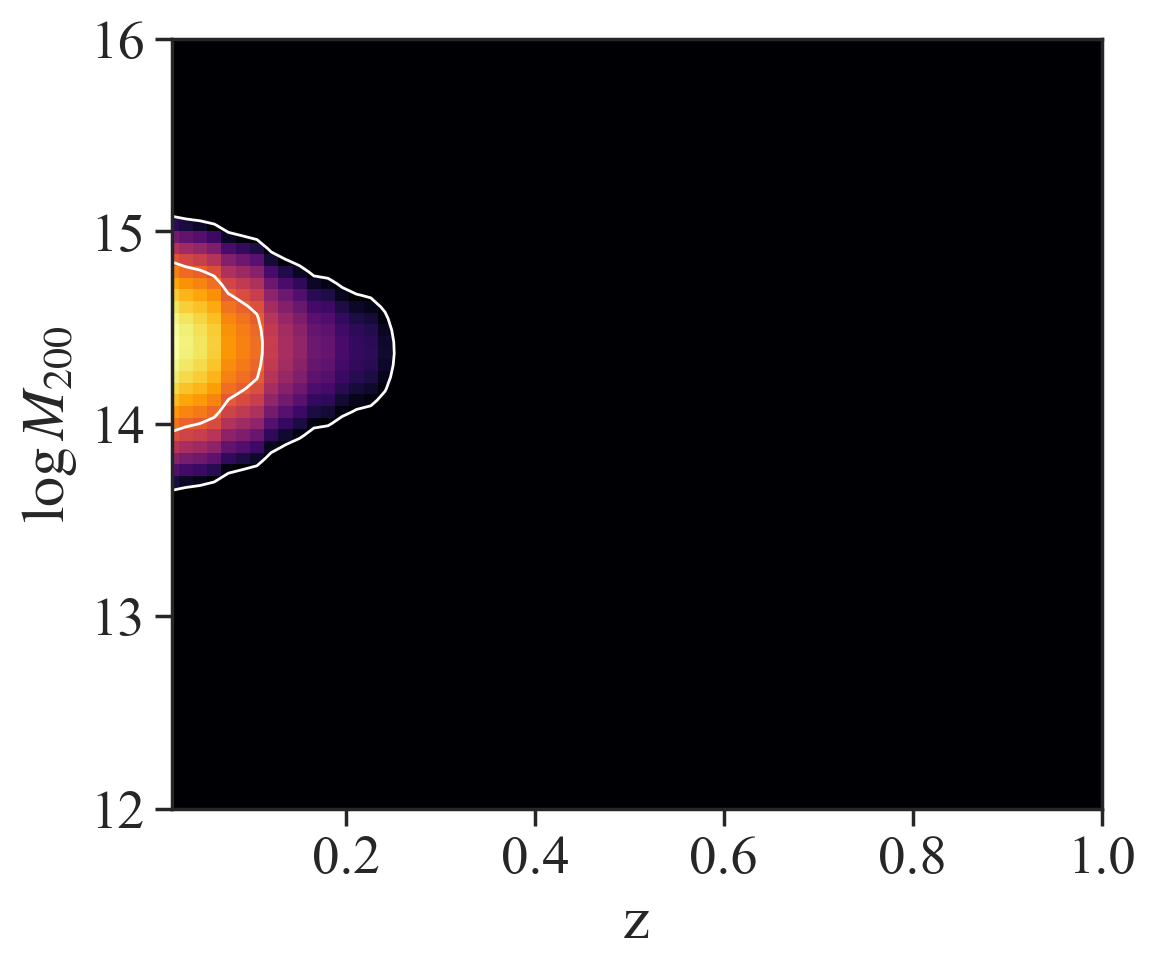

In [8]:
sensitivity_total = np.zeros((len(logMmaxs), len(z_grid)))
for frb_z in df.z_sample:
    DMmean_FRB = np.interp(frb_z, z_grid, DMmean)
    DMstd_FRB = np.interp(frb_z, z_grid, DMvar)
    dDMmean_dz_FRB = np.where(z_grid<frb_z, dDMmean_dz, 0)
    dDMvar_dz_FRB = np.where(z_grid<frb_z, dDMvar_dz[-1], 0)
    
    d_mu_l_dlogM = -(1/(DMmean_FRB**2 + DMstd_FRB**2 + (100/(1+frb_z))**2)) * 0.5*dDMvarsq_z_dlogM_interp_z(frb_z)
    d_mu_l_dz = (1/(DMmean_FRB**2 + DMstd_FRB**2 + (100/(1+frb_z))**2)) * ((DMmean_FRB*dDMmean_dz_FRB) + (2*dDMmean_dz_FRB*(DMstd_FRB**2 + (100/(1+frb_z))**2)/DMmean_FRB) - (0.5 * dDMvar_dz_FRB))
    
    sensitivity = -d_mu_l_dlogM[:, None]*d_mu_l_dz[None, :]/(np.interp(frb_z, z_grid, sigma_l)**2)
    sensitivity[sensitivity<1e-10] = 1e-10
    sensitivity[np.isnan(sensitivity)] = 1e-10
    sensitivity_total += sensitivity
sensitivity_total /= np.max(sensitivity_total)
sensitivity_MZ_CURRENT = sensitivity_total


fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.pcolormesh(z_grid, logMmaxs, sensitivity_total, cmap="inferno", norm=LogNorm(0.33, 1))

Z, M = np.meshgrid(z_grid, logMmaxs)
contours = ax.contour(Z, M, sensitivity_total, levels=levels, colors='white', linewidths=1.0)

ax.set_xlabel("z")
ax.set_ylabel(r"$\log M_\mathrm{200}$")

ax.set_xlim(z_grid[1], 1)
ax.set_ylim(12, 16)

# np.save("data/sensitivity/sensitivity_currentFRBs_DMvar_MZ.npy", np.array([Z, M, sensitivity_MZ_CURRENT]))


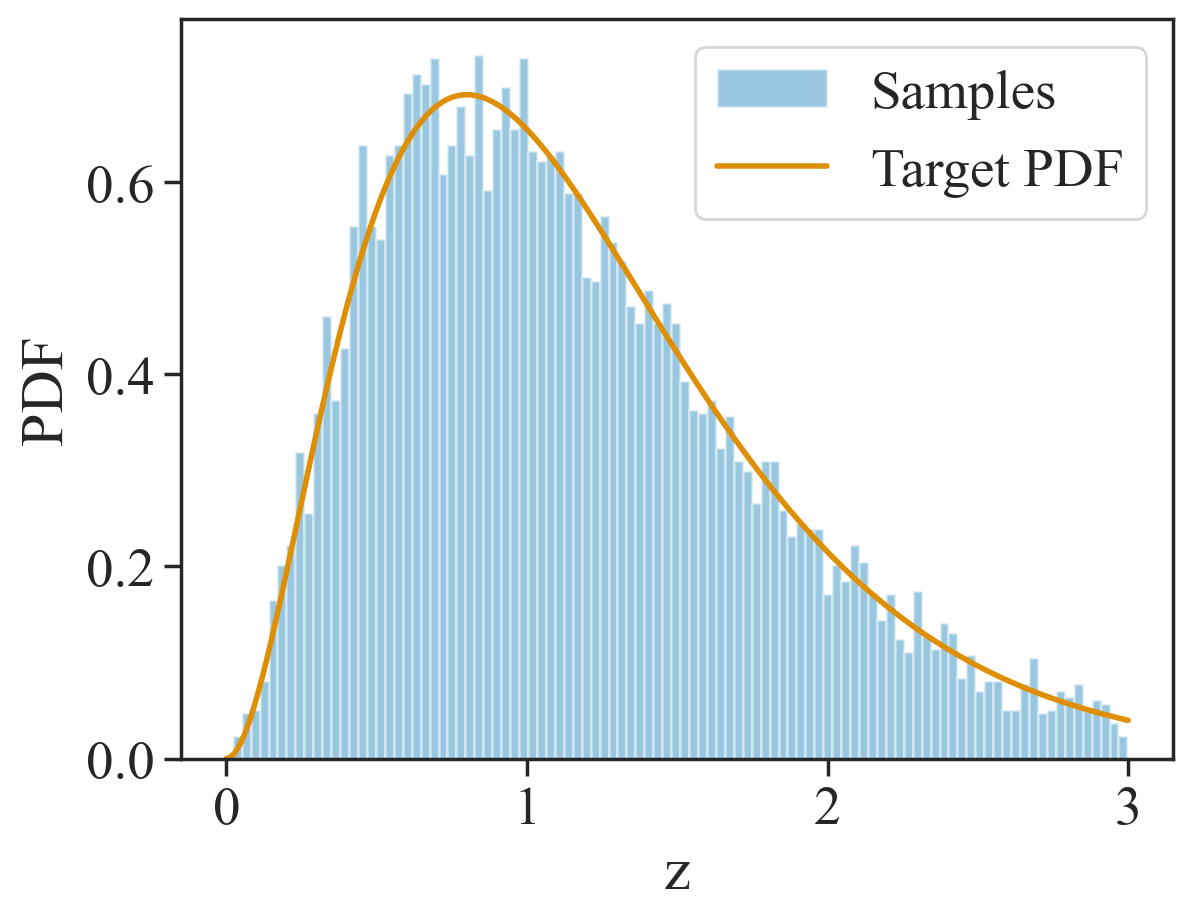

In [9]:
pdf = (z_grid**2)*np.exp(-2.5*z_grid)
pdf = np.clip(pdf, 0, None)
pdf /= np.trapz(pdf, z_grid)
cdf = np.cumsum(pdf * np.gradient(z_grid))
cdf /= cdf[-1]

inv_cdf = interp1d(
    cdf, z_grid,
    bounds_error=False,
    fill_value=(z_grid[0], z_grid[-1])
)

N = 10000
u = np.random.rand(N)
z_samples = inv_cdf(u)

plt.hist(z_samples, bins=100, density=True, alpha=0.4, label="Samples")
plt.plot(z_grid, pdf, lw=2, label="Target PDF")
plt.xlabel("z")
plt.ylabel("PDF")
plt.legend()
plt.show()


(12.0, 16.0)

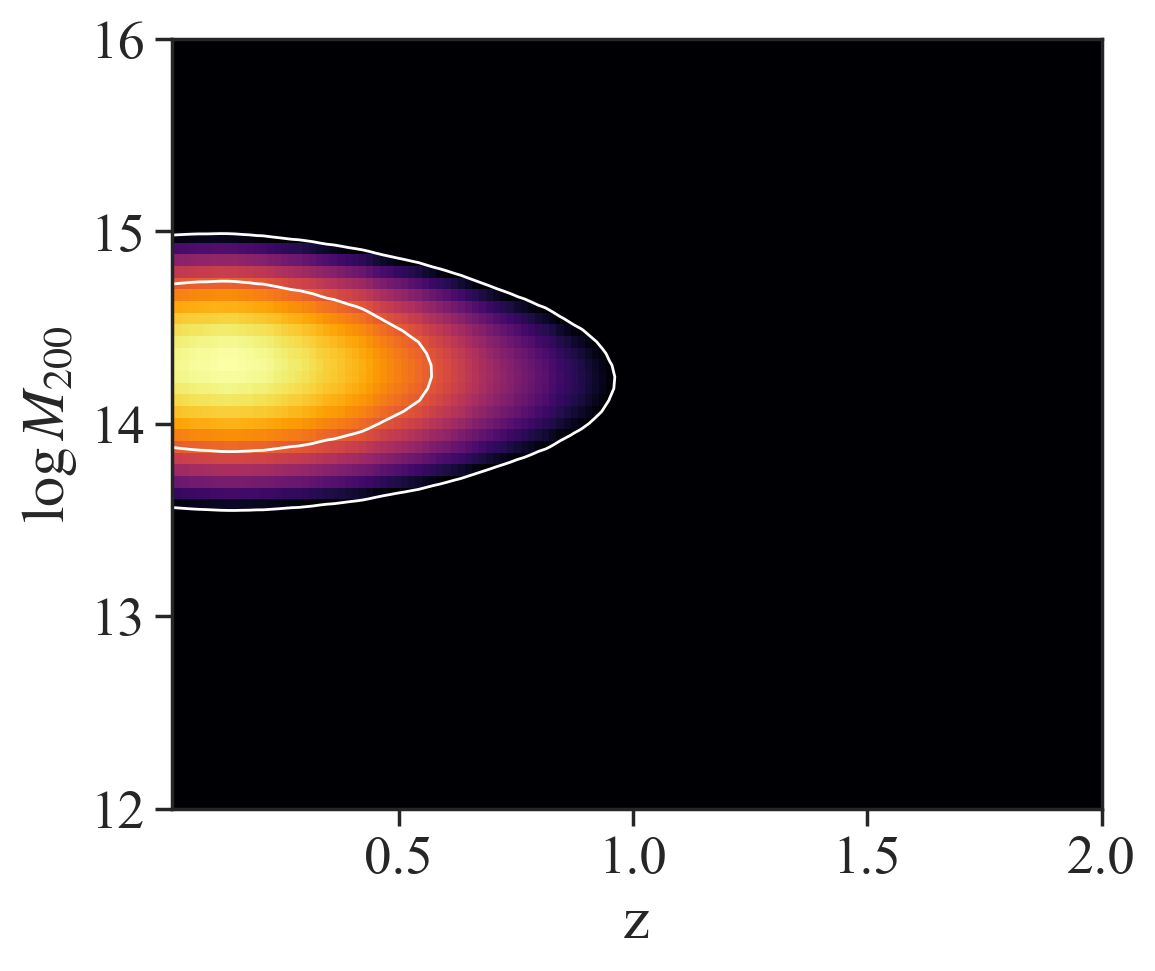

In [10]:
sensitivity_total = np.zeros((len(logMmaxs), len(z_grid)))
for frb_z in z_samples:
    DMmean_FRB = np.interp(frb_z, z_grid, DMmean)
    DMstd_FRB = np.interp(frb_z, z_grid, DMvar) + (100/(1+frb_z))
    dDMmean_dz_FRB = np.where(z_grid<frb_z, dDMmean_dz, 0)
    dDMvar_dz_FRB = np.where(z_grid<frb_z, dDMvar_dz[-1], 0)
    
    d_mu_l_dlogM = -(1/(DMmean_FRB**2 + DMstd_FRB**2)) * 0.5*dDMvarsq_z_dlogM_interp_z(frb_z)
    d_mu_l_dz = (1/(DMmean_FRB**2 + DMstd_FRB**2)) * ((DMmean_FRB*dDMmean_dz_FRB) + (2*dDMmean_dz_FRB*(DMstd_FRB**2 + (100/(1+frb_z))**2)/DMmean_FRB) - (0.5 * dDMvar_dz_FRB))
    
    sensitivity = -d_mu_l_dlogM[:, None]*d_mu_l_dz[None, :]/(np.interp(frb_z, z_grid, sigma_l)**2)
    sensitivity[sensitivity<1e-10] = 1e-10
    sensitivity[np.isnan(sensitivity)] = 1e-10
    sensitivity_total += sensitivity
sensitivity_total /= np.max(sensitivity_total)
sensitivity_MZ_CURRENT = sensitivity_total


fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.pcolormesh(z_grid, logMmaxs, sensitivity_total, cmap="inferno", norm=LogNorm(0.33, 1))

Z, M = np.meshgrid(z_grid, logMmaxs)
contours = ax.contour(Z, M, sensitivity_total, levels=levels, colors='white', linewidths=1.0)

ax.set_xlabel("z")
ax.set_ylabel(r"$\log M_\mathrm{200}$")

ax.set_xlim(z_grid[1], 2)
ax.set_ylim(12, 16)

# np.save("data/sensitivity/sensitivity_DSA2000FRBs.npy", np.array([Z, M, sensitivity_MZ_CURRENT]))
